## Семинар: "Методы оптимизации"

In [1]:
from functools import partial

import numpy as np
import torch
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib import animation
from mpl_toolkits import mplot3d
from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from IPython.display import HTML
%matplotlib inline
plt.rc('animation', html='html5')

C:\Users\Uliana\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


На этом семинаре мы попробуем реализовать и сравнить различные методы оптимизации: SGD, Momentum, NAG, Adagrad, RMSProp, AdaDelta.

### Реализация методов

Для всех экспериментов подберите параметры так, чтобы метод сошелся к ближайшему локальному минимуму. Все методы следует запускать из одной и той же точки.

In [2]:
# https://github.com/dzlab/deepprojects/blob/master/visualization/Optimizers_in_Action.ipynb

def grid_samples(center=[0, 0], offset=5, size=100):
    range1 = np.linspace(center[0]-offset, center[0]+offset, size)
    range2 = np.linspace(center[1]-offset, center[1]+offset, size)
    return torch.from_numpy(np.stack(np.meshgrid(range1, range2))).float()


def mse(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1)


def msre(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1).sqrt()


def mae(y, y_hat):
    return ((y - y_hat).abs()).mean(axis=-1)


class LossAnimator:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.size = len(X)

    def loss_func(self, W, loss):
        shape = W.shape
        return loss((self.X @ W.view(shape[0], -1)).T, self.y).view(shape[1:])

    def plot_loss_funcs(self, weights, fcts, titles, view=(20, 50)):
        num_fcts = len(fcts)
        fig = plt.figure(figsize=(7 * num_fcts,7))
        for i in range(num_fcts):
            loss = self.loss_func(weights, loss=fcts[i])
            ax = fig.add_subplot(1, num_fcts, i+1, projection='3d')
            ax.plot_surface(*weights, loss, cmap='viridis')
            ax.set_xlabel('w0'); ax.set_ylabel('w1'); ax.set_zlabel('Loss')
            ax.set_title(titles[i])
            ax.view_init(*view)

    def _init_animation(self, epochs, train_data):
        self.train_data = train_data
        self.epochs = epochs
        self.nmethods = len(train_data)

        weights = grid_samples(offset=5)

        max_loss = max([data['losses'].max() for data in train_data.values()])
        loss_curve = self.loss_func(weights, loss=mse)
        colors = cm.rainbow(np.linspace(0, 1, self.nmethods))


        self.fig = plt.figure(figsize=(14, 8))
        self.gs = GridSpec(2, 2, width_ratios=[1, 2.5])

        self.ax0 = self.fig.add_subplot(self.gs[0,0])
        self.lines0 = {
            name: self.ax0.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax0.scatter(self.X[:,0], self.y, c='orange', label='Ground truth')
        self.ax0.set_ylim(self.y.min(), self.y.max())
        self.ax0.set_title('Ground truth & Model', fontsize=16)
        self.ax0.legend(loc='lower right')

        self.ax1 = self.fig.add_subplot(self.gs[:,1], projection='3d')
        self.ax1.plot_surface(*weights, loss_curve-0.5, cmap='viridis', alpha=0.8)
        self.ax1.view_init(50, 70)
        self.lines1 = {
            name: self.ax1.plot3D([], [], [], c=c, marker='o', alpha=0.9, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax1.set_title('Loss', fontsize=16, pad=20)
        self.ax1.set_xlabel('w0')
        self.ax1.set_ylabel('w1')
        self.ax1.set_zlabel('Loss')
        self.ax1.legend()

        self.ax2 = self.fig.add_subplot(self.gs[1,0])
        self.lines2 = {
            name: self.ax2.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax2.set_title('Loss', fontsize=16)
        self.ax2.set_ylabel('loss')
        self.ax2.set_ybound(0, max_loss)
        self.ax2.set_xlim(0, epochs)
        self.ax2.legend(loc='center right')

        self.fig.tight_layout()
        self.fig.subplots_adjust(top=0.85)

        plt.close()

        return self.fig

    def _animate(self, i):
        steps = np.arange(i+1)
        left = max(0, i-20)
        for name, data in self.train_data.items():
            # plot ground truth & model
            self.lines0[name].set_data(self.X[:, 0], self.X @ data['weights'][i])

            # plot loss (output of the sampling)
            self.lines1[name].set_data(data['weights'][left:i+1, 0], data['weights'][left:i+1, 1])
            self.lines1[name].set_3d_properties(data['losses'][left:i+1])

            self.lines2[name].set_data(steps, data['losses'][:i+1])

        self.fig.suptitle(f'Epoch: {i}/{self.epochs}', fontsize=22)

    def animate(self, epochs, train_data, step_skip=1):
        self._init_animation(epochs, train_data)
        anim = animation.FuncAnimation(self.fig, self._animate, frames=range(0, epochs, step_skip), interval=100 * step_skip)
        return HTML(anim.to_html5_video())

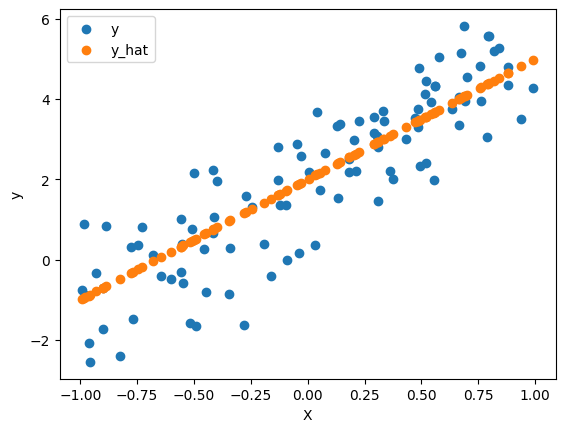

In [3]:
size = 100
X = torch.ones(size, 2)
X[:, 0].uniform_(-1., 1)

y_hat = 3 * X[:, 0] + 2
y = y_hat + torch.randn(size)

loss_animator = LossAnimator(X, y)

plt.scatter(loss_animator.X[:,0], loss_animator.y, label='y');
plt.scatter(loss_animator.X[:,0], y_hat, label='y_hat');
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

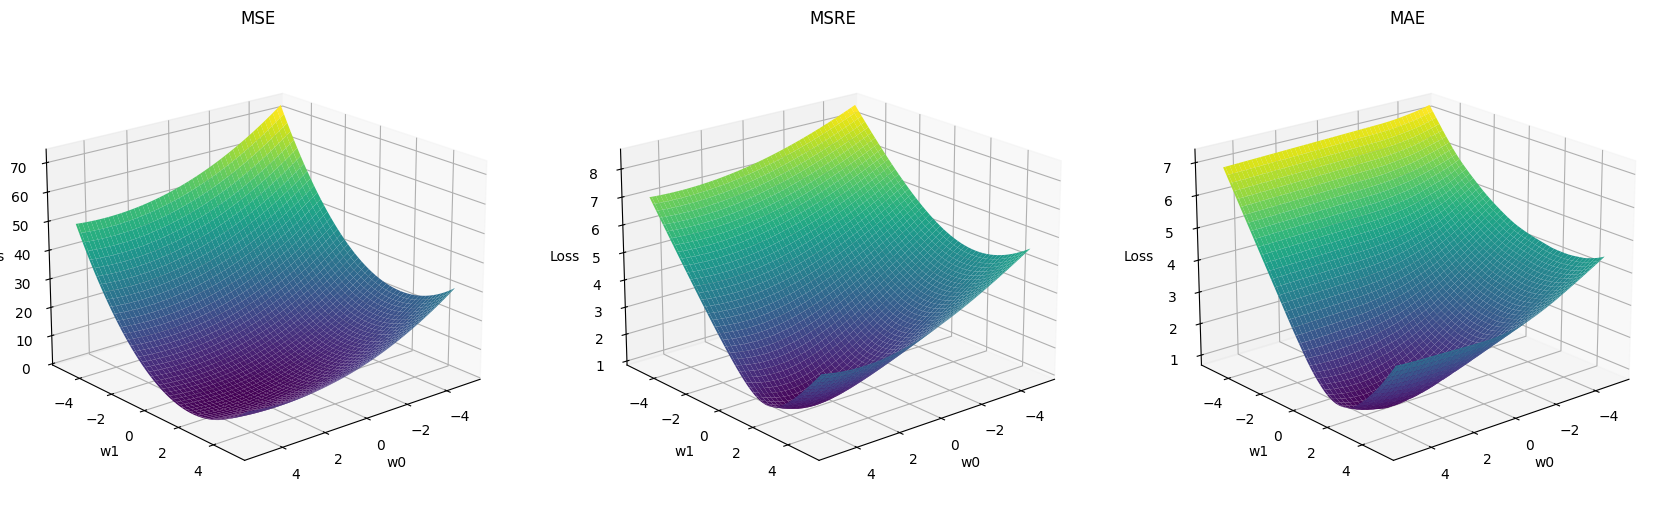

In [4]:
weights = grid_samples()
loss_animator.plot_loss_funcs(weights, [mse, msre, mae], ['MSE', 'MSRE', 'MAE'])

In [5]:
class Optimizer:
    def __init__(self, params):
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def pre_step(self):
        pass

    def step(self):
        pass

    def update_param(self, p):
        raise NotImplementedError()


In [6]:
def optimize_function(fn, optim, optim_args, start_point, num_iter = 50):
    weigths = nn.Parameter(torch.FloatTensor(start_point), requires_grad=True)

    optim = optim(params=[weigths], **optim_args)
    points = []
    losses = []
    for i in range(num_iter):
        if hasattr(optim, 'pre_step'):
            optim.pre_step()
        loss = fn(weigths)
        points.append(weigths.data.detach().clone())
        losses.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    points = torch.stack(points, axis=0)
    losses = torch.FloatTensor(losses)
    return points, losses


In [7]:
def compare_optimizers(
    loss_animator,
    fn,
    optim_list,
    start_point,
    num_iter = 50,
    step_skip = 1
):
    data = {}
    loss_func = partial(loss_animator.loss_func, loss=fn)
    for name, optim, args in tqdm(optim_list):
        points, losses = optimize_function(loss_func, optim, args, start_point, num_iter)
        data[name] = {
            'weights': points,
            'losses': losses,
        }

    return loss_animator.animate(num_iter, data, step_skip=step_skip)

#### SGD
$$\theta_t = \theta_{t-1} - \eta \sum_{i_1, ..., i_k} \nabla_{\theta} J_{i} (\theta_{t-1})$$

In [8]:
class SGD(Optimizer):
    def __init__(self, params, lr=1e-2):
        super().__init__(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad


#### Momentum
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [9]:
class Momentum(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= self.prev_momentum[i]

#### Nesterov Accelerated Gradient (NAG)
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1} - \gamma \nu_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [10]:
class NAG(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= (1 + self.gamma) * self.prev_momentum[i] - self.gamma * prev_momentum

#### AdaGrad
$$G_t = \sum_{k=0}^t g_{k}^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [11]:
class AdaGrad(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2):
        super().__init__(params)
        self.epsilon = epsilon
        self.eta = eta

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.G[i] += p.grad ** 2
                p -= self.eta * p.grad / torch.sqrt(self.G[i] + self.epsilon)

#### RMSProp
$$G_t = \gamma G_{t-1} + (1 - \gamma) g_t^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [12]:
class RMSProp(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2, gamma=0.9):
        super().__init__(params)
        self.eta = eta
        self.epsilon = epsilon
        self.gamma = gamma

        self.G = [torch.zeros(p.shape) for p in self.params]


    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                self.G[i] = self.gamma * self.G[i] + (1 - self.gamma) * (p.grad ** 2)
                p -= self.eta / torch.sqrt(self.G[i] + self.epsilon) * p.grad

In [13]:
from functools import partial

points, losses = optimize_function(
    partial(loss_animator.loss_func, loss=mse),
    SGD,
     {'lr': 1e-2},
    start_point=[-4, -4],
    num_iter=100
)

In [ ]:
compare_optimizers(
    loss_animator,
    mae,
    [
        ['SGD', SGD, {'lr': 1e-1}],
        ['Momentum', NAG, {'lr': 1e-1}],
        ['NAG', NAG, {'lr': 1e-1}],
        ['AdaGrad', AdaGrad, {'eta' : 1}],
        ['RMSProp', RMSProp, {'eta' : 1}],
    ],
    start_point=[-4, -4],
    num_iter=100
)

###  Домашнее задание: Обучение нейронной сети + Подбор шага

В этом задании вам нужно:
1) Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. **(2 балла)**
2) Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1). **(3 балла)**

Ссылки:
- https://arxiv.org/abs/1711.05101 (AdamW, статья)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html (AdamW, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html (LinearLR, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html (CosineAnnealingLR, PyTorch)

In [ ]:
!wget www.di.ens.fr/~lelarge/MNIST.tar.gz
!tar -zxvf MNIST.tar.gz

In [14]:
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

In [28]:
class Adam(Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9,0.999), eps=1e-8, weight_decay=0.0):
        super().__init__(params)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.weight_decay = weight_decay
        
        self.m = {p: torch.zeros_like(p) for p in self.params}
        self.v = {p: torch.zeros_like(p) for p in self.params}
        self.step_num = {p: 0 for p in self.params}

    def step(self):
        beta1, beta2 = self.betas
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue

                grad = p.grad
                if self.weight_decay != 0:
                    grad = grad.add(p, alpha=self.weight_decay)

                self.step_num[p] += 1
                t = self.step_num[p]

                m = self.m[p].mul(beta1).add(grad, alpha=1 - beta1)
                v = self.v[p].mul(beta2).addcmul(grad, grad, value=1 - beta2)

                self.m[p], self.v[p] = m, v

                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                p -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

In [33]:
class AdamW(Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9,0.999), eps=1e-8, weight_decay=1e-2):
        super().__init__(params)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.m = {p: torch.zeros_like(p) for p in self.params}
        self.v = {p: torch.zeros_like(p) for p in self.params}
        self.step_num = {p: 0 for p in self.params}

    def step(self):
        beta1, beta2 = self.betas
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue

                grad = p.grad
                
                if self.weight_decay != 0:
                    p -= self.lr * self.weight_decay * p

                self.step_num[p] += 1
                t = self.step_num[p]

                m = self.m[p].mul(beta1).add(grad, alpha=1 - beta1)
                v = self.v[p].mul(beta2).addcmul(grad, grad, value=1 - beta2)

                self.m[p], self.v[p] = m, v

                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                p -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

In [17]:
import math

In [18]:
class LRScheduler:
    def __init__(self, optimizer: Optimizer):
        self.optimizer = optimizer
        self.base_lrs = [optimizer.lr] if hasattr(optimizer, 'lr') else [0.01] * len(optimizer.params)
        self.last_iter = 0
        
    def step(self):
        raise NotImplementedError

In [19]:
class LinearLR(LRScheduler):
    def __init__(
        self,
        optimizer: Optimizer,
        start_factor: float = 0.1,
        end_factor: float = 1.0,
        total_iters: int = 100
    ):
        super().__init__(optimizer)
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_iters = total_iters

    def step(self):
        self.last_iter += 1
        factor = self.start_factor + (self.end_factor - self.start_factor) * min(self.last_iter / self.total_iters, 1.0)
        
        for p in self.optimizer.params:
            if hasattr(self.optimizer, 'lr'):
                self.optimizer.lr = self.base_lrs[0] * factor

class CosineAnnealing(LRScheduler):
    def __init__(
            self,
            optimizer: Optimizer,
            T_max: int = 20,
            eta_min: float = 0.01
        ):
        super().__init__(optimizer)
        self.T_max = T_max
        self.eta_min = eta_min

    def step(self):
        self.last_iter += 1
        factor = self.eta_min + 0.5 * (1.0 - self.eta_min) * (1 + math.cos(math.pi * self.last_iter / self.T_max))
        
        for p in self.optimizer.params:
            if hasattr(self.optimizer, 'lr'):
                self.optimizer.lr = self.base_lrs[0] * factor

In [20]:
import os

In [21]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [22]:
seed_everything(42)

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [24]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            out = model(x)                     
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

In [25]:
def train_one_epoch(model, optimizer, loader, scheduler=None):
    model.train()
    total_loss = 0.0
    total = 0
    correct = 0
    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        out = model(x)          
        loss = criterion(out, y)
        loss.backward()

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        optimizer.zero_grad()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    return total_loss / total, correct / total

In [31]:
def run_single(opt_name, sched_name, epochs=8, lr=1e-2, wd=1e-4):
    model = CNN() 
    
    if opt_name == 'sgd':
        optimizer = SGD(model.parameters(), lr=lr)
    elif opt_name == 'adam':
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=wd)
    
    scheduler = None
    total_iters = epochs * len(train_loader)
    if sched_name == 'linear':
        scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=total_iters)
    elif sched_name == 'cosine':
        scheduler = CosineAnnealing(optimizer, T_max=total_iters, eta_min=0.0)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'lrs': []}

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, optimizer, train_loader, scheduler)
        te_loss, te_acc = evaluate(model, test_loader) 

        lrs = [optimizer.lr] if hasattr(optimizer, 'lr') else [0.0]
        
        history['lrs'].append(lrs)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        print(f"{opt_name:5s} {str(sched_name):6s}: "
              f"Epoch {epoch}/{epochs-1} train_loss={tr_loss:.4f} train_acc={tr_acc:.2f} "
              f", test_loss={te_loss:.4f} test_acc={te_acc:.2f}")

    return history

In [32]:
EPOCHS = 2
BASE_LR = 1e-2
WD = 1e-4

scheds = [None, 'linear', 'cosine']
opts = ['sgd', 'adam', 'adamw']

results = {}
for opt in opts:
    for sch in scheds:
        key = f"{opt.upper()} {'NONE' if sch is None else sch.upper()}"
        print(key)
        hist = run_single(opt, sch, epochs=EPOCHS, lr=BASE_LR, wd=WD)
        results[key] = hist

SGD NONE
sgd   None  : Epoch 0/1 train_loss=0.3712 train_acc=0.89 , test_loss=0.1194 test_acc=0.96
sgd   None  : Epoch 1/1 train_loss=0.1025 train_acc=0.97 , test_loss=0.0717 test_acc=0.98
SGD LINEAR
sgd   linear: Epoch 0/1 train_loss=0.9002 train_acc=0.77 , test_loss=0.2643 test_acc=0.92
sgd   linear: Epoch 1/1 train_loss=0.1861 train_acc=0.94 , test_loss=0.0973 test_acc=0.97
SGD COSINE
sgd   cosine: Epoch 0/1 train_loss=0.3595 train_acc=0.89 , test_loss=0.1266 test_acc=0.96
sgd   cosine: Epoch 1/1 train_loss=0.1159 train_acc=0.97 , test_loss=0.0999 test_acc=0.97
ADAM NONE
adam  None  : Epoch 0/1 train_loss=1.1013 train_acc=0.59 , test_loss=0.3236 test_acc=0.90
adam  None  : Epoch 1/1 train_loss=0.2763 train_acc=0.92 , test_loss=0.2552 test_acc=0.92
ADAM LINEAR
adam  linear: Epoch 0/1 train_loss=0.1820 train_acc=0.95 , test_loss=0.0746 test_acc=0.98
adam  linear: Epoch 1/1 train_loss=0.0929 train_acc=0.97 , test_loss=0.0778 test_acc=0.98
ADAM COSINE
adam  cosine: Epoch 0/1 train_loss=

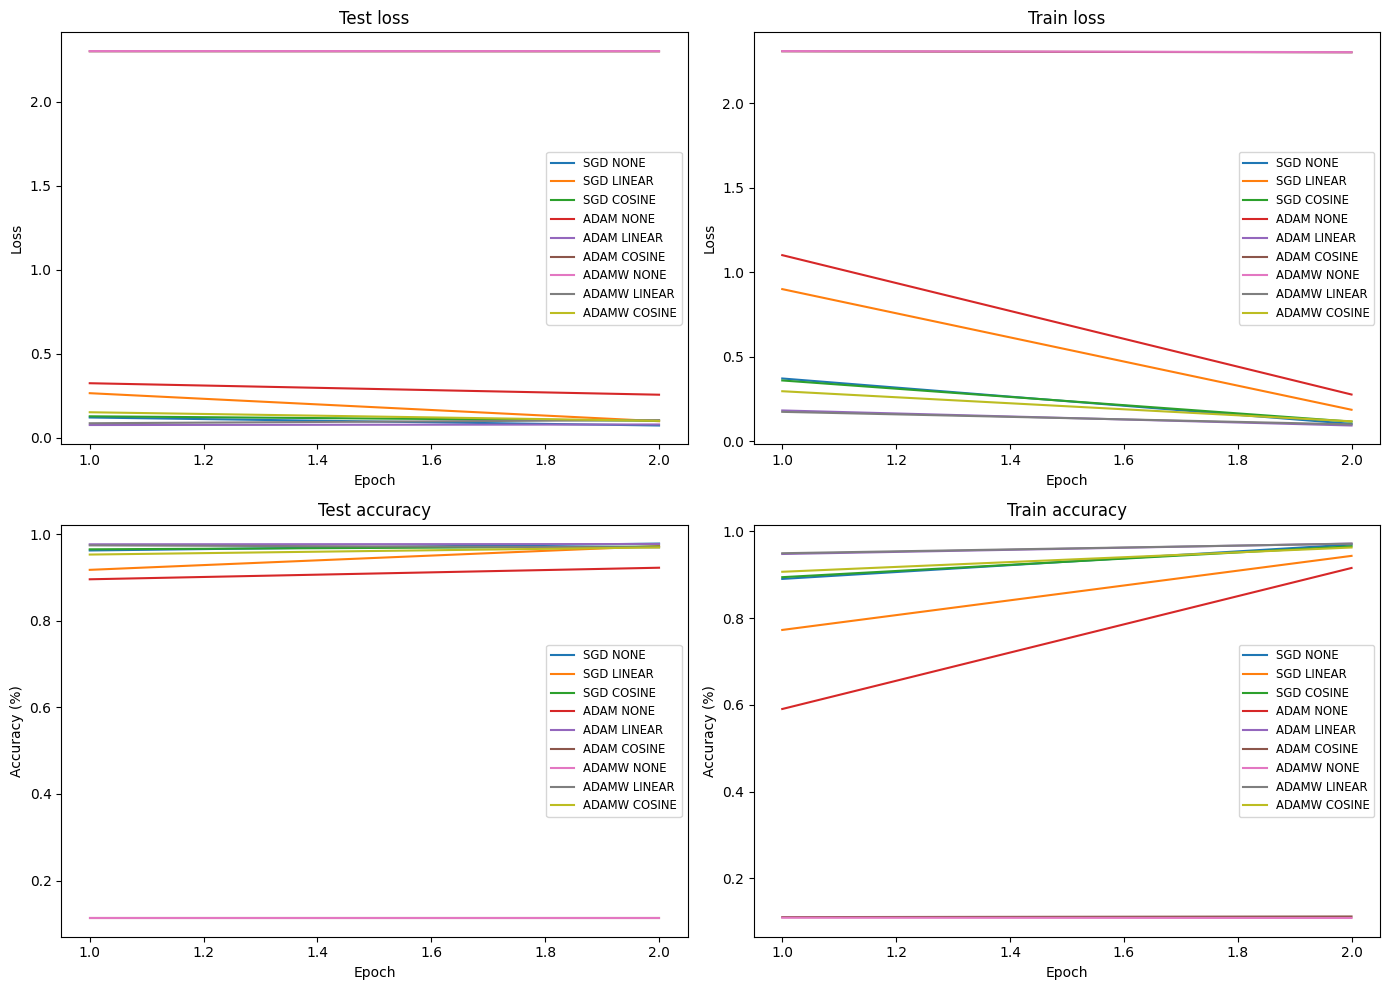

In [34]:
plt.figure(figsize=(14,10))

# Test loss
plt.subplot(2,2,1)
for k,h in results.items():
    plt.plot(range(1,EPOCHS+1), h['test_loss'], label=k)
plt.title("Test loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(fontsize='small')

# Train loss
plt.subplot(2,2,2)
for k,h in results.items():
    plt.plot(range(1,EPOCHS+1), h['train_loss'], label=k)
plt.title("Train loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(fontsize='small')

# Test accuracy
plt.subplot(2,2,3)
for k,h in results.items():
    plt.plot(range(1,EPOCHS+1), h['test_acc'], label=k)
plt.title("Test accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(fontsize='small')

# Train accuracy
plt.subplot(2,2,4)
for k,h in results.items():
    plt.plot(range(1,EPOCHS+1), h['train_acc'], label=k)
plt.title("Train accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(fontsize='small')

plt.tight_layout()
plt.show()


#### Feedback (опционально)

Здесь вы можете оставить список опечаток из лекции или семинара:

- Your text here

Здесь вы можете оставить комментарии по лекции или семинару:

- Your text here